# STEP 7 · 시각화 (보고서용 그래프)

### 재현성 안전장치 3가지
1. **ROOT 경로** — 어디서 실행하든 경로가 안 깨진다.
2. **FIG.mkdir** — 출력 폴더가 없어도 자동 생성(savefig 실패 방지).
3. **OS별 폰트 분기** — Windows/macOS/Linux 자동 선택.

In [1]:
import sys, platform
from pathlib import Path

# === ROOT 경로 방식 (실행 위치 무관) ===
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

DATA_RAW   = ROOT / "data" / "raw"
OUT_TABLES = ROOT / "outputs" / "tables"
FIG        = ROOT / "outputs" / "figures"
FIG.mkdir(parents=True, exist_ok=True)        # 폴더 없으면 자동 생성

import pyreadstat, pandas as pd, numpy as np
from scipy.stats import zscore
import matplotlib.pyplot as plt
from src.variable_mapping import MEDIA_LABELS
from src.stats_helpers import welch_ttest, star
import warnings; warnings.filterwarnings('ignore')

# === OS별 한글 폰트 분기 ===
if platform.system() == "Darwin":            # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                                        # Linux
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# === 데이터 로드 ===
df23,_ = pyreadstat.read_sav(DATA_RAW/"journalist_2023.sav")
df25,_ = pyreadstat.read_sav(DATA_RAW/"journalist_2025.sav")

def build(df,yr):
    d=df.copy()
    if yr==2025:
        d['fatigue']=d['q5'];d['ai_user']=(d['q38']==1)
        d['benefit']=d[['q39_1','q39_2','q39_3']].mean(1)
        d['risk']=d[['q39_4','q39_5','q39_6']].mean(1)
        d['jobthreat']=d['q39_6']
        d['burnout']=d[['q21_3','q21_4']].mean(1);d['satis']=d['q19_1']
    else:
        d['fatigue']=d['q6'];d['ai_user']=d['q43_9'].isna()
        d['benefit']=d[['q45_1','q45_2','q45_3']].mean(1)
        d['risk']=d[['q45_4','q45_5']].mean(1)
        d['jobthreat']=d['q45_5']
        d['burnout']=d[['q26_3','q26_4']].mean(1);d['satis']=d['q24_1']
    d['role_imp']=d[[f'q2_{i}' for i in range(1,8)]].mean(1)
    d['role_perf']=d[[f'q3_{i}' for i in range(1,8)]].mean(1)
    d['role_gap']=d['role_imp']-d['role_perf']
    return d
d23=build(df23,2023);d25=build(df25,2025)

C1,C2,C3='#185FA5','#D85A30','#0F6E56'
SRC='자료: 한국언론진흥재단 2023·2025 언론인 조사 원본 데이터 재분석' 

### 그림 1 — 2023→2025 변화 비교
y축은 '비율(%)'. 단, 지표마다 비율의 의미가 달라 주석으로 명시.

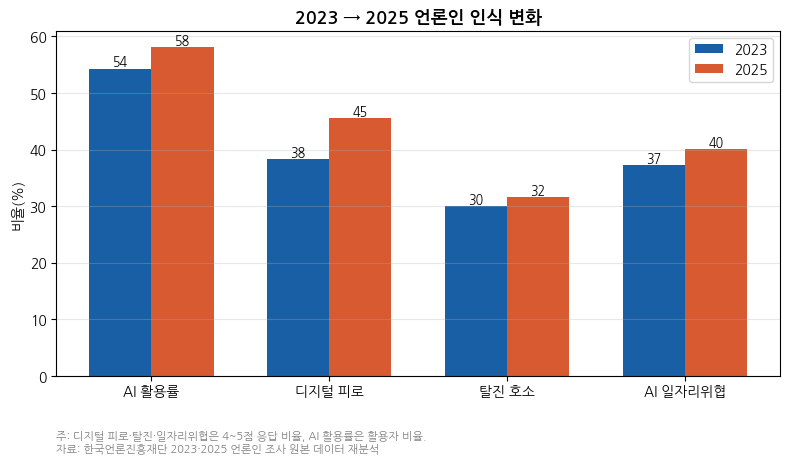

In [2]:
fig,ax=plt.subplots(figsize=(8,4.8))
labels=['AI 활용률','디지털 피로','탈진 호소','AI 일자리위협']
v23=[d23['ai_user'].mean()*100,(d23['fatigue']>=4).mean()*100,(d23['burnout']>=4).mean()*100,(d23['jobthreat']>=4).mean()*100]
v25=[d25['ai_user'].mean()*100,(d25['fatigue']>=4).mean()*100,(d25['burnout']>=4).mean()*100,(d25['jobthreat']>=4).mean()*100]
x=np.arange(len(labels));w=0.35
ax.bar(x-w/2,v23,w,label='2023',color=C1)
ax.bar(x+w/2,v25,w,label='2025',color=C2)
ax.set_xticks(x);ax.set_xticklabels(labels)
ax.set_ylabel('비율(%)')
ax.set_title('2023 → 2025 언론인 인식 변화',fontsize=13,weight='bold')
ax.legend();ax.grid(axis='y',alpha=0.3)
for i,(a,b) in enumerate(zip(v23,v25)):
    ax.text(i-w/2,a+0.5,f'{a:.0f}',ha='center',fontsize=9)
    ax.text(i+w/2,b+0.5,f'{b:.0f}',ha='center',fontsize=9)
note='주: 디지털 피로·탈진·일자리위협은 4~5점 응답 비율, AI 활용률은 활용자 비율.\n'+SRC
ax.text(0.0,-0.22,note,transform=ax.transAxes,ha='left',fontsize=8,color='gray')
plt.tight_layout();plt.savefig(FIG/'fig1_change.png',dpi=200,bbox_inches='tight');plt.show()

### 그림 2 — AI 활용자 vs 비활용자 (Welch t-검정)

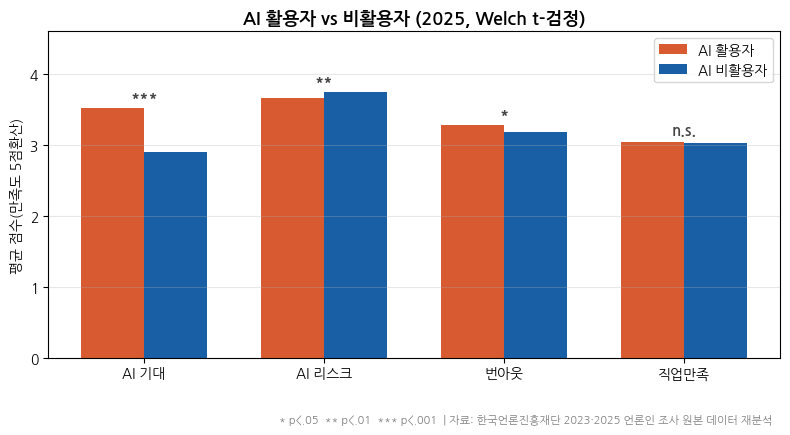

In [3]:
fig,ax=plt.subplots(figsize=(8,4.5))
cols=['benefit','risk','burnout','satis']
metrics=['AI 기대','AI 리스크','번아웃','직업만족']
u=[d25[d25['ai_user']][c].mean() for c in cols]
n=[d25[~d25['ai_user']][c].mean() for c in cols]
stars=[star(welch_ttest(d25[d25['ai_user']][c],d25[~d25['ai_user']][c])[1]) for c in cols]
u[3]/=2;n[3]/=2
x=np.arange(len(metrics));w=0.35
ax.bar(x-w/2,u,w,label='AI 활용자',color=C2)
ax.bar(x+w/2,n,w,label='AI 비활용자',color=C1)
ax.set_xticks(x);ax.set_xticklabels(metrics);ax.set_ylabel('평균 점수(만족도 5점환산)')
ax.set_title('AI 활용자 vs 비활용자 (2025, Welch t-검정)',fontsize=13,weight='bold')
for i,s in enumerate(stars):
    ax.text(i,max(u[i],n[i])+0.12,s,ha='center',fontsize=11,weight='bold',color='#444')
ax.set_ylim(0,4.6);ax.legend();ax.grid(axis='y',alpha=0.3)
ax.text(0.99,-0.20,'* p<.05  ** p<.01  *** p<.001  | '+SRC,
        transform=ax.transAxes,ha='right',fontsize=8,color='gray')
plt.tight_layout();plt.savefig(FIG/'fig2_groups.png',dpi=200,bbox_inches='tight');plt.show()

### 그림 3 — JTSI 분포

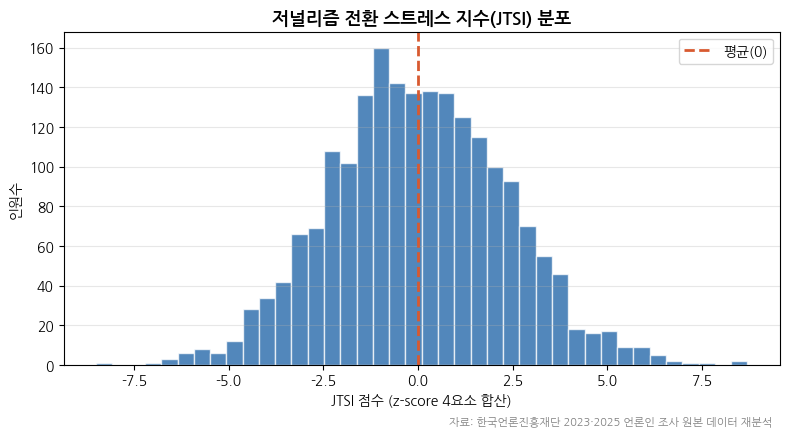

In [4]:
comp=['fatigue','risk','role_gap','burnout']
dd=d25.dropna(subset=comp).copy()
for c in comp:dd[c+'_z']=zscore(dd[c])
dd['JTSI']=dd[[c+'_z' for c in comp]].sum(1)
fig,ax=plt.subplots(figsize=(8,4.5))
ax.hist(dd['JTSI'],bins=40,color=C1,alpha=0.75,edgecolor='white')
ax.axvline(0,color=C2,ls='--',lw=2,label='평균(0)')
ax.set_xlabel('JTSI 점수 (z-score 4요소 합산)');ax.set_ylabel('인원수')
ax.set_title('저널리즘 전환 스트레스 지수(JTSI) 분포',fontsize=13,weight='bold')
ax.legend();ax.grid(axis='y',alpha=0.3)
ax.text(0.99,-0.18,SRC,transform=ax.transAxes,ha='right',fontsize=8,color='gray')
plt.tight_layout();plt.savefig(FIG/'fig3_jtsi_dist.png',dpi=200,bbox_inches='tight');plt.show()

### 그림 4 — 매체유형별 JTSI (전체 평균 대비)

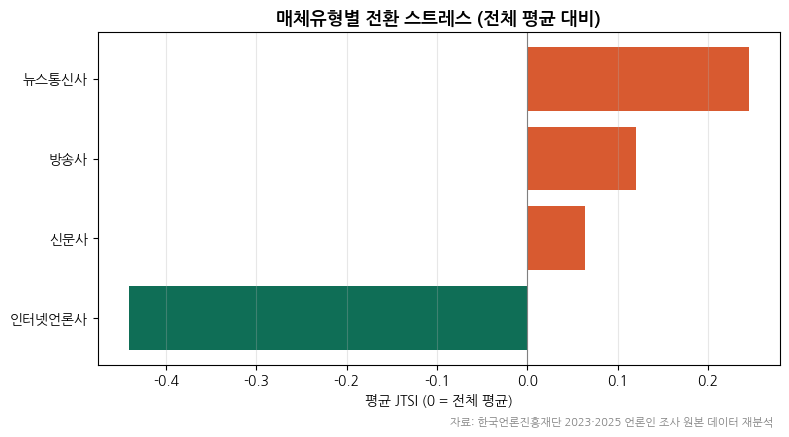

In [5]:
fig,ax=plt.subplots(figsize=(8,4.5))
m=dd.groupby('SQ1')['JTSI'].mean().sort_values()
colors=[C3 if v<0 else C2 for v in m.values]
ax.barh([MEDIA_LABELS[int(i)] for i in m.index],m.values,color=colors)
ax.axvline(0,color='gray',lw=0.8)
ax.set_xlabel('평균 JTSI (0 = 전체 평균)')
ax.set_title('매체유형별 전환 스트레스 (전체 평균 대비)',fontsize=13,weight='bold')
ax.grid(axis='x',alpha=0.3)
ax.text(0.99,-0.18,SRC,transform=ax.transAxes,ha='right',fontsize=8,color='gray')
plt.tight_layout();plt.savefig(FIG/'fig4_media.png',dpi=200,bbox_inches='tight');plt.show()

### 그림 5 — AI 가이드라인 인지율
> q40=가이드라인 인지 여부(1=예). 인지율 43.1%.

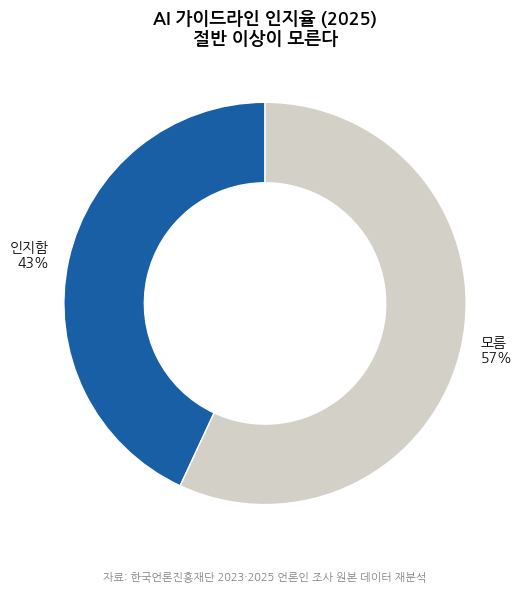

In [6]:
fig,ax=plt.subplots(figsize=(6,6))
know=(df25['q40']==1).mean()*100
ax.pie([know,100-know],labels=[f'인지함\n{know:.0f}%',f'모름\n{100-know:.0f}%'],
       colors=[C1,'#D3D1C7'],startangle=90,
       wedgeprops=dict(width=0.4,edgecolor='white'))
ax.set_title('AI 가이드라인 인지율 (2025)\n절반 이상이 모른다',fontsize=13,weight='bold')
ax.text(0.5,-0.05,SRC,transform=ax.transAxes,ha='center',fontsize=8,color='gray')
plt.tight_layout();plt.savefig(FIG/'fig5_guideline.png',dpi=200,bbox_inches='tight');plt.show()